# Window length optimization

Tutorial 1 of 2 on tuning `DSTFT`'s parameters (tutorial 2: [`hop_optimization.ipynb`](hop_optimization.ipynb) covers `hop_length`). This one is about `win_length` / `theta`: the analysis window's length.

`win_length` controls how many samples each analysis frame looks at. It sets a hard trade-off: a **short** window resolves *when* something happens (good time resolution) but blurs *which frequency* it is (poor frequency resolution); a **long** window does the opposite. A fixed window length is a single point on that trade-off, chosen once for the whole signal.

`DSTFT` lets `win_length` be a **learnable tensor** instead of a constant, via `window_mode`:

- `"fixed"` — a constant, not learnable (the `torch.stft` baseline).
- `"constant"` — one learnable scalar, shared by the whole spectrogram.
- `"time"` — one learnable value per frame (can shrink around transients, grow over stationary stretches).
- `"frequency"` — one learnable value per frequency bin.
- `"time-frequency"` — one learnable value per (frequency bin, frame) cell — the most flexible, and the most parameters to fit.

This notebook: (1) shows the trade-off concretely with a fixed window, (2) trains `win_length` with gradient descent under each `window_mode`, (3) reads the learned window-length maps to see *where* it adapted and why, (4) checks reconstruction still works.

In [1]:
import torch


device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
print(device, torch.__version__)
torch.manual_seed(1802)

%load_ext autoreload
%autoreload 2
%matplotlib inline

cpu 2.13.0+cu130


## 1. Signal and loss

In [2]:
def entropy_loss(x: torch.Tensor):
    """A simple loss function to encourage spectrogram sparsity."""
    x1 = torch.reshape(x, (x.shape[0], -1))  # B, N
    probs = torch.div(x1.T, x1.sum(dim=-1)).T  # B, N
    entropy = -(
        probs * torch.clamp(torch.log(probs), min=torch.finfo(x.dtype).min)
    ).sum(dim=-1)  # B
    return entropy.mean()

In [3]:
from math import pi


# A signal with a slow tone and a fast tone: no single window length is
# optimal for both at once, which is exactly the case adaptive windows help with.
duration = 1024
sr = 5
t = torch.arange(0, duration, 1 / sr, dtype=dtype, device=device) / float(duration)

slow_tone = torch.cos(2 * pi * 40.0 * t * sr)
fast_tone = torch.cos(2 * pi * 180.0 * t * sr)
# the fast tone only appears in the second half of the signal
mask = (t > 0.5).float()

x = (slow_tone + mask * fast_tone)[None, :].to(device)

## 2. The trade-off, with a *fixed* window

Before optimizing anything: a short fixed window and a long fixed window on the *same* signal, to see the trade-off directly rather than take it on faith.

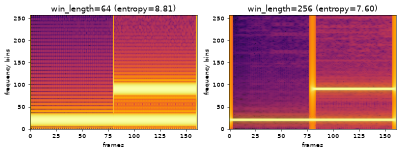

In [4]:
import matplotlib.pyplot as plt

from dstft import DSTFT


plt.rcParams["figure.dpi"] = 45  # keep saved notebook outputs small

n_fft = 512
hop_length = 32

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, w in zip(axes, [64, 256], strict=True):
    dstft = DSTFT(win_length=w, n_fft=n_fft, hop_length=hop_length, window_mode="fixed")
    dstft.initialize(x)
    spec, _ = dstft(x)
    loss = entropy_loss(spec).item()
    dstft.plot_spec(
        spec,
        ax=ax,
        show=False,
        colorbar=False,
        title=f"win_length={w} (entropy={loss:.2f})",
    )
fig.tight_layout()
plt.show()

`win_length=64` localizes the fast tone's onset sharply (visible vertical edge halfway through) but smears its frequency into a wide band. `win_length=256` does the opposite: a crisp frequency line, but the onset is blurred across many frames. Neither setting is good for *both* tones at once — which is exactly the problem an adaptive window is meant to fix.

## 3. Letting `win_length` adapt: `window_mode`

In [5]:
win_length = 256
epochs = 3_000
lr = 1
patience = 9
factor = 0.1
lr_stop = 1e-3

window_modes = ["fixed", "constant", "time", "frequency", "time-frequency"]
results = {}
trained = {}

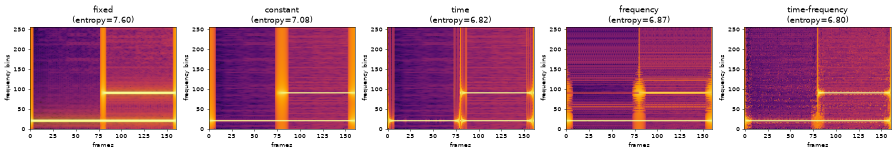

In [6]:
# one shared figure (rather than one figure per mode) to keep this notebook's
# saved size small
fig, axes = plt.subplots(1, len(window_modes), figsize=(4 * len(window_modes), 3.5))

for ax, window_mode in zip(axes, window_modes, strict=True):
    dstft = DSTFT(
        win_length=win_length,
        n_fft=n_fft,
        hop_length=hop_length,
        window_mode=window_mode,
    )
    dstft.initialize(x)

    if window_mode == "fixed":
        spec, _ = dstft(x)
        final_loss = entropy_loss(spec).item()
    else:
        optimizer = torch.optim.Adam(dstft.parameters(), lr=lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer=optimizer, mode="min", factor=factor, patience=patience
        )
        for _ in range(epochs):
            optimizer.zero_grad(set_to_none=True)
            spec, _ = dstft(x)
            loss = entropy_loss(spec)
            loss.backward()
            optimizer.step()
            scheduler.step(loss.detach())
            if optimizer.param_groups[0]["lr"] < lr_stop:
                break
        spec, _ = dstft(x)
        final_loss = entropy_loss(spec).item()

    results[window_mode] = final_loss
    trained[window_mode] = dstft
    dstft.plot_spec(
        spec,
        ax=ax,
        show=False,
        colorbar=False,
        title=f"{window_mode}\n(entropy={final_loss:.2f})",
    )

fig.tight_layout()
plt.show()

Lower entropy means a sparser, more concentrated spectrogram. Modes that let the window adapt (`"time"`, `"frequency"`, `"time-frequency"`) resolve both the slow and the fast tone better than any single fixed window could, at the cost of more parameters to fit — and more training time (`"time-frequency"` has the most parameters and the slowest, least stable convergence of the three).

In [7]:
for window_mode, loss in results.items():
    print(f"{window_mode:>15s}: entropy = {loss:.4f}")

          fixed: entropy = 7.5969
       constant: entropy = 7.0756
           time: entropy = 6.8155
      frequency: entropy = 6.8714
 time-frequency: entropy = 6.8002


### Where did the window actually adapt?

Entropy alone doesn't show *what* the optimizer changed. `plot_win_lengths` reads out the learned `win_length` tensor itself — one heatmap per mode, on the same `win_length_min`/`win_length_max` color scale so they're comparable.

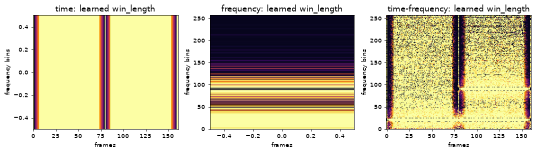

In [8]:
from dstft.visualization import plot_win_lengths


adaptive_modes = ["time", "frequency", "time-frequency"]
fig, axes = plt.subplots(1, len(adaptive_modes), figsize=(4 * len(adaptive_modes), 3.5))

for ax, window_mode in zip(axes, adaptive_modes, strict=True):
    dstft = trained[window_mode]
    plot_win_lengths(
        dstft.win_length,
        ax=ax,
        show=False,
        colorbar=False,
        vmin=dstft.win_length_min,
        vmax=dstft.win_length_max,
        title=f"{window_mode}: learned win_length",
    )

fig.tight_layout()
plt.show()

For `"time"`, expect the learned length to *drop* around the frame index where the fast tone begins (roughly the halfway point) and stay high elsewhere: the optimizer trades frequency resolution for time resolution exactly where the signal actually changes, and not before. `"frequency"` and `"time-frequency"` read similarly, along their own axes — this is the mechanism, not just a number going down.

## 4. Reconstruction still works

Whatever `window_mode` you pick, `DSTFT.inverse` reconstructs the time-domain signal from the (possibly learned) transform — this is what makes `DSTFT` usable as a differentiable front-end inside a larger model, not just an analysis tool. See [`inverse.ipynb`](inverse.ipynb) for a closer look at reconstruction accuracy across every `window_mode`; here's a quick check with the trained `"time"` model from above.

reconstruction error: 6.261301166432531e-08


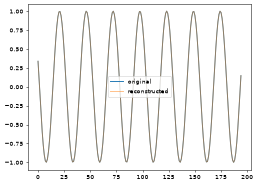

In [9]:
dstft = trained["time"]
spec, stft = dstft(x)
x_hat = dstft.inverse(stft)

# Plot an interior slice: WOLA normalization divides by a near-zero denominator
# at the signal edges, where fewer frames overlap, which inflates error there.
plt.plot(x[0, 5:200].detach().cpu(), label="original")
plt.plot(x_hat[0, 5:200].detach().cpu(), alpha=0.5, label="reconstructed")
plt.legend()
print("reconstruction error:", (x - x_hat).abs().mean().item())

## Next

[`hop_optimization.ipynb`](hop_optimization.ipynb) covers the other learnable parameter, `hop_length` — frame *spacing* rather than frame *width*. Optimizing the window's *shape* (not just its length) or the `magnitude_power` exponent are natural follow-ups, left for a future notebook.